### 1. Load the data

In [3]:
# Mount Google Drive (skip this cell if you uploaded the CSV directly to Colab's file browser instead)
from google.colab import drive
drive.mount('/content/drive')

# ---- EDIT THIS PATH to match where you placed the CSV in your Drive ----
DATA_PATH = "/content/drive/MyDrive/IT2011_Group_Project folder/data/raw/Lung Cancer.csv"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (890000, 17)


,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Why this technique is needed for this dataset
Age, bmi, and cholesterol level are all on very different numeric scales  age
ranges from 4 to 104, bmi from 16 to 45, and cholesterol level from 150 all the
way up to 300. That difference in scale is actually a problem for certain models.
Algorithms like SVM, K-Means, and Neural Networks work by calculating distances
or gradients between numbers, and if one column's values are naturally much
bigger than another's, the model can end up treating it as more important just
because of its size, not because it's actually more useful for prediction.

Scaling fixes this by putting all the numeric columns onto a comparable range, so
no single feature ends up dominating the model purely because of the units it
happens to be measured in.

In [4]:
num_cols = ["age", "bmi", "cholesterol_level"]
print(df[num_cols].agg(["min", "max", "mean", "std"]))


             age        bmi  cholesterol_level
min     4.000000  16.000000         150.000000
max   104.000000  45.000000         300.000000
mean   55.007008  30.494172         233.633916
std     9.994485   8.368539          43.432278


### 3. Implementation

In [5]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaled = df.copy()

# Standardization (z-score): mean 0, std 1 -- good default for SVM / Neural Networks
standard_scaler = StandardScaler()
scaled[[c + "_standard" for c in num_cols]] = standard_scaler.fit_transform(scaled[num_cols])

# Min-Max normalization: squashes values into [0, 1] -- useful when a model
# needs bounded input, or for visual comparability across features
minmax_scaler = MinMaxScaler()
scaled[[c + "_minmax" for c in num_cols]] = minmax_scaler.fit_transform(scaled[num_cols])

scaled[[
    "age", "age_standard", "age_minmax",
    "bmi", "bmi_standard", "bmi_minmax",
    "cholesterol_level", "cholesterol_level_standard", "cholesterol_level_minmax",
]].head()


,age,age_standard,age_minmax,bmi,bmi_standard,bmi_minmax,cholesterol_level,cholesterol_level_standard,cholesterol_level_minmax
0,64.0,0.899796,0.60,29.4,-0.130748,0.462069,199,-0.797424,0.326667
1,50.0,-0.500977,0.46,41.2,1.279296,0.868966,280,1.067550,0.866667
2,65.0,0.999851,0.61,44.0,1.613882,0.965517,268,0.791257,0.786667
3,51.0,-0.400922,0.47,43.0,1.494387,0.931034,241,0.169599,0.606667
4,37.0,-1.801696,0.33,19.7,-1.289852,0.127586,178,-1.280936,0.186667


In [6]:
print("After StandardScaler (should be ~0 mean, ~1 std):")
print(scaled[[c + "_standard" for c in num_cols]].agg(["mean", "std"]))
print("\nAfter MinMaxScaler (should be exactly [0, 1]):")
print(scaled[[c + "_minmax" for c in num_cols]].agg(["min", "max"]))


After StandardScaler (should be ~0 mean, ~1 std):
      age_standard  bmi_standard  cholesterol_level_standard
mean  7.504609e-18 -3.581135e-16                3.008550e-16
std   1.000001e+00  1.000001e+00                1.000001e+00

After MinMaxScaler (should be exactly [0, 1]):
     age_minmax  bmi_minmax  cholesterol_level_minmax
min         0.0         0.0                       0.0
max         1.0         1.0                       1.0


### 4. EDA visualization

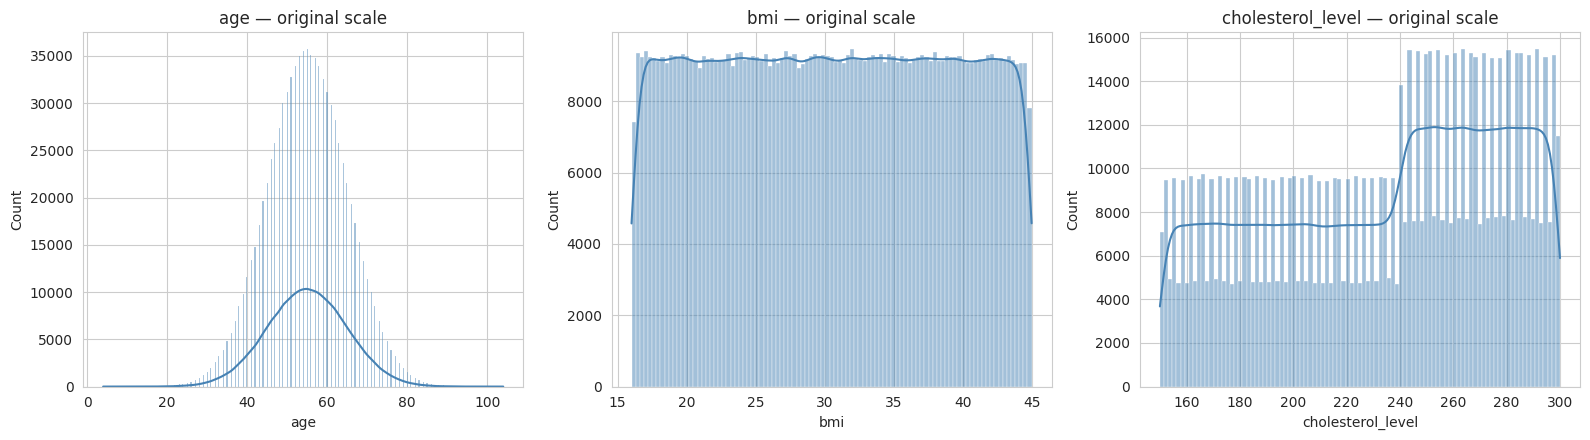

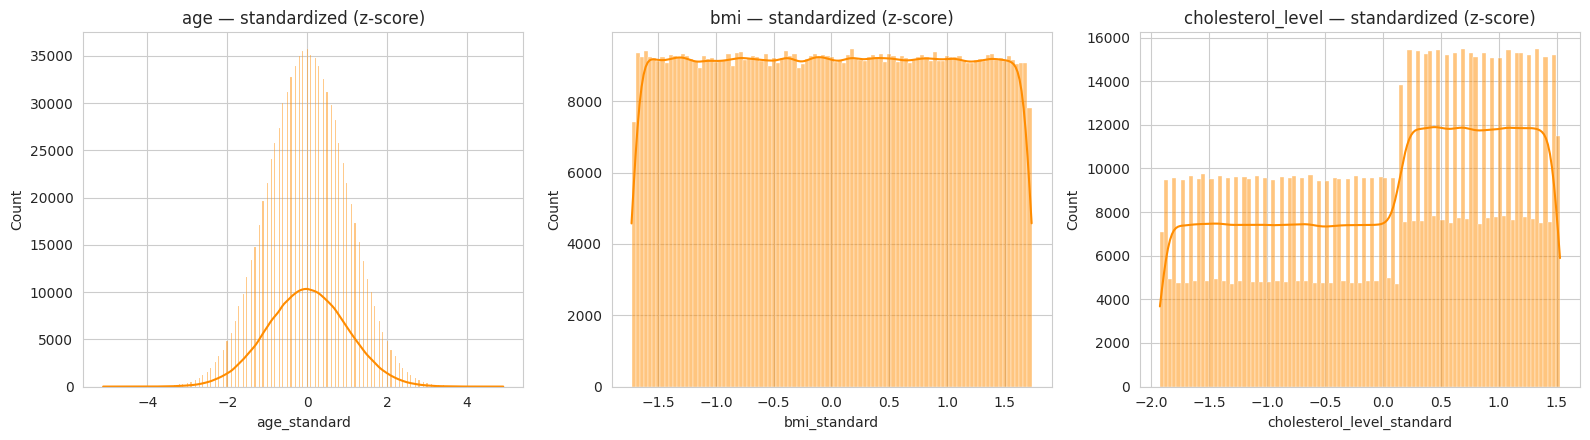

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(df[c], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"{c} — original scale")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, num_cols):
    sns.histplot(scaled[c + "_standard"], kde=True, ax=ax, color="darkorange")
    ax.set_title(f"{c} — standardized (z-score)")
plt.tight_layout()
plt.show()


### 5. Interpretation
cholesterol level already have a roughly bell shaped or uniform distribution
without any heavy skew. Because of that, standardizing them mainly just shifts
them to be centered around 0 without actually changing their shape  the
before and after histograms look basically identical, just with different
numbers on the x-axis. That's a good sign, since it means z-score scaling isn't
distorting the underlying data, just putting it on a more usable scale.

Based on this, I'd recommend using StandardScaler on these features for the
SVM and Neural Network models later in Step 3, since both of those are
sensitive to feature scale. Decision Trees, on the other hand, don't need any
scaling at all - they split the data based on raw threshold values, so the
scale of the numbers doesn't affect how they work.